# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

**Objective:** Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

**Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository) — schema-matched sample data is bundled in `data/bank_marketing.csv`. See the README for a note on data provenance.

**Skills demonstrated:** Classification modeling, feature encoding, model interpretability (SHAP), customer behavior analysis.


## 1. Load and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                              roc_curve, roc_auc_score, ConfusionMatrixDisplay)
import shap

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("data/bank_marketing.csv")
print(df.shape)
df.head()

(4000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,24,technician,married,tertiary,no,1656,no,no,cellular,22,aug,54,1,-1,2,unknown,no
1,78,management,married,tertiary,no,-1754,no,no,cellular,19,may,3,7,-1,2,unknown,no
2,69,unknown,married,secondary,no,7156,yes,no,unknown,23,jul,43,5,-1,1,unknown,no
3,52,services,married,primary,no,6846,no,no,cellular,26,oct,172,8,-1,1,unknown,yes
4,51,admin.,married,secondary,no,-4921,no,no,unknown,17,jul,31,3,-1,2,unknown,no


In [2]:
df.info()
print()
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4000 non-null   int64
 1   job        4000 non-null   str  
 2   marital    4000 non-null   str  
 3   education  4000 non-null   str  
 4   default    4000 non-null   str  
 5   balance    4000 non-null   int64
 6   housing    4000 non-null   str  
 7   loan       4000 non-null   str  
 8   contact    4000 non-null   str  
 9   day        4000 non-null   int64
 10  month      4000 non-null   str  
 11  duration   4000 non-null   int64
 12  campaign   4000 non-null   int64
 13  pdays      4000 non-null   int64
 14  previous   4000 non-null   int64
 15  poutcome   4000 non-null   str  
 16  y          4000 non-null   str  
dtypes: int64(7), str(10)
memory usage: 531.4 KB

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact     

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4000.0,NaN,NaN,NaN,56.589,22.521376,18.0,37.0,56.0,76.0,95.0
job,4000,12,blue-collar,934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4000,3,married,2396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4000,4,secondary,2027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4000,2,no,3909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,4000.0,NaN,NaN,NaN,1420.1795,3035.032593,-9800.0,-684.0,1430.5,3463.5,11969.0
housing,4000,2,yes,2230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4000,2,no,3402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4000,3,cellular,2607,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,4000.0,NaN,NaN,NaN,14.404,8.071095,1.0,8.0,14.0,21.0,28.0


### Target distribution

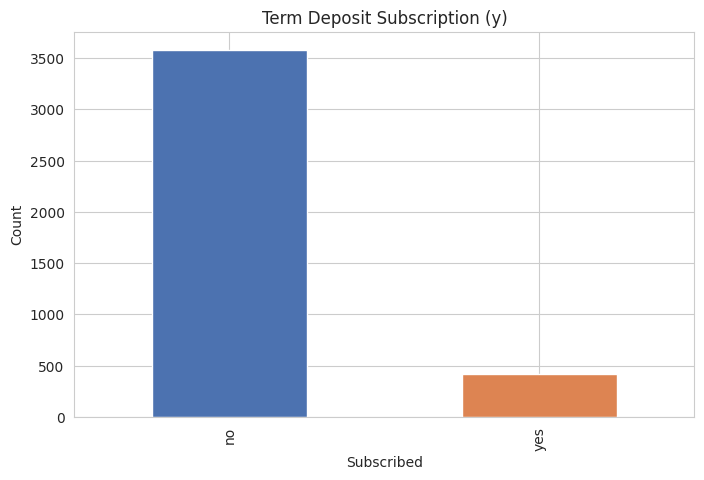

y
no     0.89475
yes    0.10525
Name: proportion, dtype: float64


In [4]:
ax = df["y"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Term Deposit Subscription (y)")
ax.set_xlabel("Subscribed")
ax.set_ylabel("Count")
plt.show()

print(df["y"].value_counts(normalize=True))

The dataset is imbalanced (~10% positive class), which is typical for marketing campaign response data. We'll keep this in mind when choosing evaluation metrics (F1-score, ROC-AUC rather than raw accuracy).

## 2. Exploratory Data Analysis

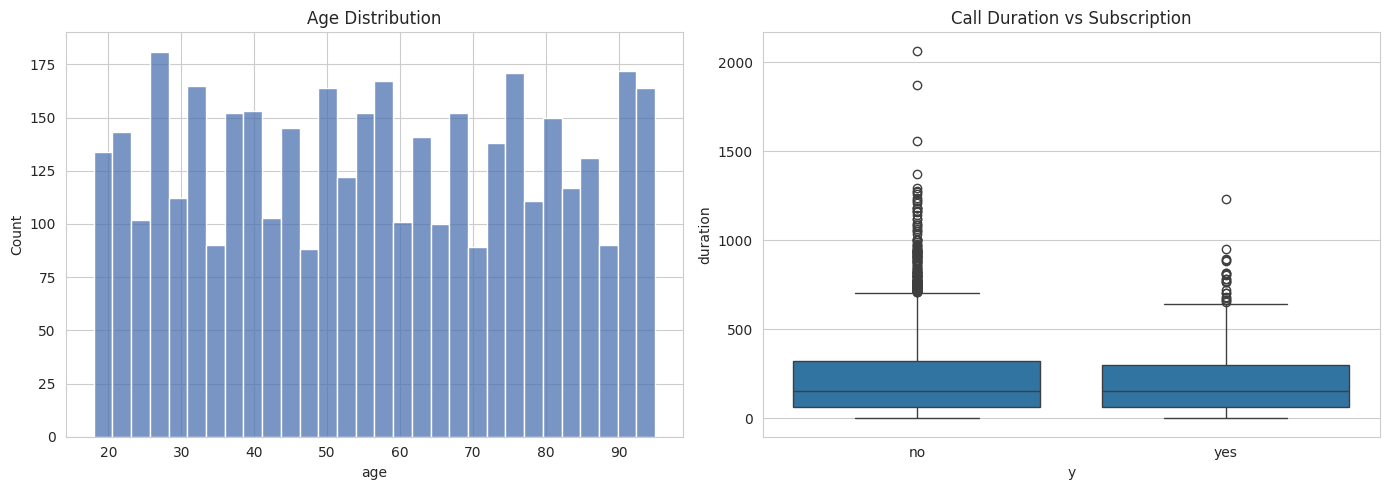

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["age"], bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Age Distribution")
sns.boxplot(x="y", y="duration", data=df, ax=axes[1])
axes[1].set_title("Call Duration vs Subscription")
plt.tight_layout()
plt.show()

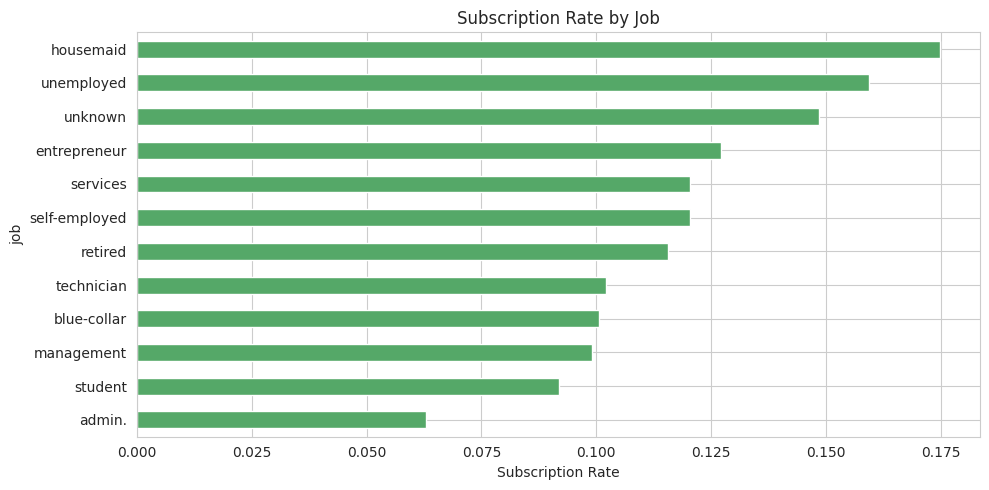

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sub_rate = df.groupby("job")["y"].apply(lambda s: (s == "yes").mean()).sort_values()
sub_rate.plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Subscription Rate by Job")
ax.set_xlabel("Subscription Rate")
plt.tight_layout()
plt.show()

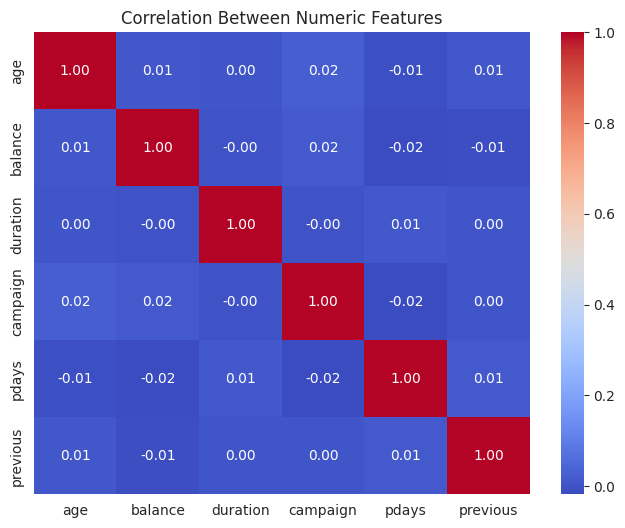

In [7]:
num_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()

## 3. Data Cleaning & Categorical Encoding

In [8]:
data = df.copy()

# Binary yes/no columns -> 0/1
binary_cols = ["default", "housing", "loan"]
for col in binary_cols:
    data[col] = data[col].map({"yes": 1, "no": 0})

target = data["y"].map({"yes": 1, "no": 0})
data = data.drop(columns=["y"])

# One-hot encode nominal categorical columns
cat_cols = ["job", "marital", "education", "contact", "month", "poutcome"]
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print(data.shape)
data.head()

(4000, 42)


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_nonexistent,poutcome_success,poutcome_unknown
0,24,0,1656,0,0,22,54,1,-1,2,...,False,False,False,False,False,False,False,False,False,True
1,78,0,-1754,0,0,19,3,7,-1,2,...,False,False,False,True,False,False,False,False,False,True
2,69,0,7156,1,0,23,43,5,-1,1,...,True,False,False,False,False,False,False,False,False,True
3,52,0,6846,0,0,26,172,8,-1,1,...,False,False,False,False,False,True,False,False,False,True
4,51,0,-4921,0,0,17,31,3,-1,2,...,True,False,False,False,False,False,False,False,False,True


## 4. Train / Test Split & Scaling

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.25, random_state=42, stratify=target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(3000, 42) (1000, 42)


## 5. Model Training: Logistic Regression & Random Forest

In [10]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Models trained.")

Models trained.


## 6. Evaluation: Confusion Matrix, F1-Score, ROC Curve

In [11]:
def evaluate(name, y_true, y_pred, y_prob):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, target_names=["no", "yes"]))
    print("F1-score:", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_prob), 3))
    print()

lr_pred = log_reg.predict(X_test_scaled)
lr_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
evaluate("Logistic Regression", y_test, lr_pred, lr_prob)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
evaluate("Random Forest", y_test, rf_pred, rf_prob)

--- Logistic Regression ---
              precision    recall  f1-score   support

          no       0.91      0.59      0.72       895
         yes       0.13      0.50      0.20       105

    accuracy                           0.58      1000
   macro avg       0.52      0.55      0.46      1000
weighted avg       0.83      0.58      0.66      1000

F1-score: 0.202
ROC-AUC: 0.581

--- Random Forest ---
              precision    recall  f1-score   support

          no       0.90      0.93      0.92       895
         yes       0.16      0.11      0.13       105

    accuracy                           0.85      1000
   macro avg       0.53      0.52      0.53      1000
weighted avg       0.82      0.85      0.83      1000

F1-score: 0.135
ROC-AUC: 0.523



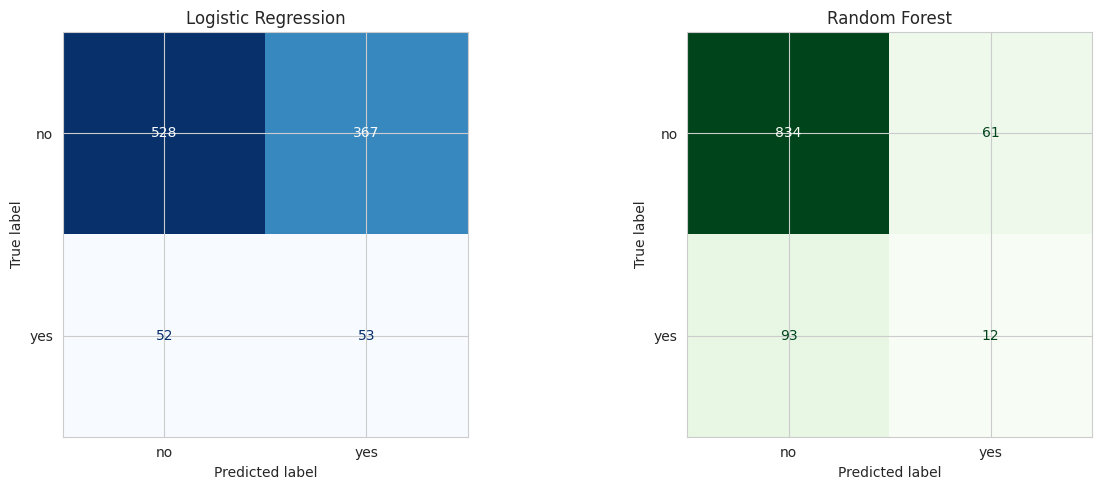

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred), display_labels=["no", "yes"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred), display_labels=["no", "yes"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()

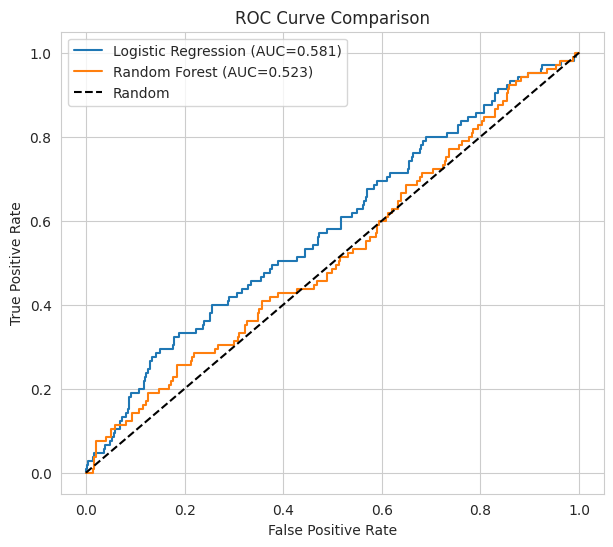

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, prob in [("Logistic Regression", lr_prob), ("Random Forest", rf_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()

**Observation:** Random Forest generally achieves a higher ROC-AUC than plain Logistic Regression on this data, capturing non-linear interactions between features like `duration`, `poutcome`, and `contact`. We use the Random Forest model for the explainability step below.

## 7. Model Interpretability with SHAP

In [14]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Newer SHAP versions return shape (n_samples, n_features, n_classes) for
# multi-class/binary output; older versions return a list [class0, class1].
if isinstance(shap_values, list):
    sv = shap_values[1]
elif np.ndim(shap_values) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values
print(np.shape(sv))

(1000, 42)


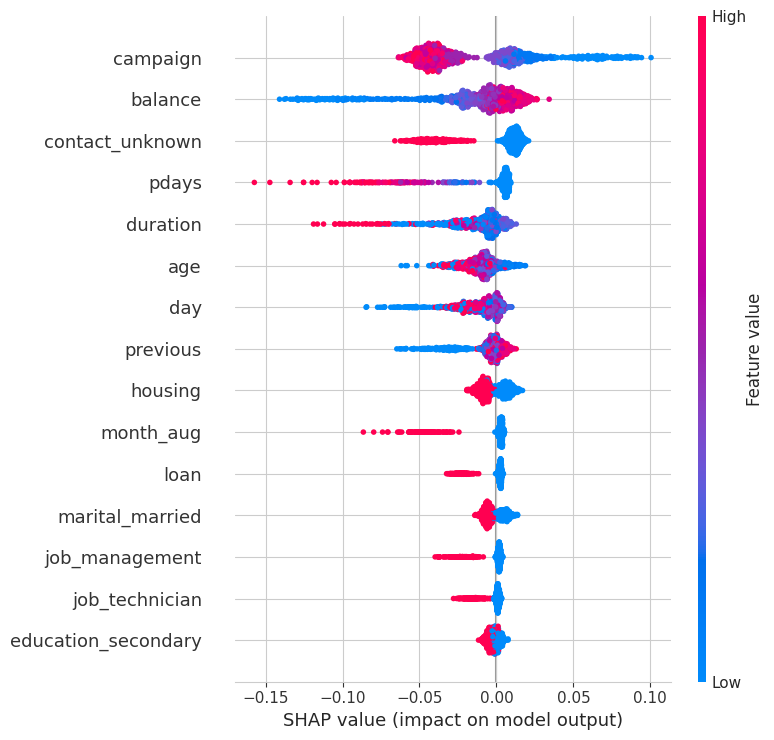

In [15]:
shap.summary_plot(sv, X_test, show=False, max_display=15)
plt.tight_layout()
plt.show()

### Explaining 5 individual predictions

In [16]:
sample_idx = X_test.reset_index(drop=True).sample(5, random_state=1).index

for i in sample_idx:
    pred_label = "yes" if rf_pred[i] == 1 else "no"
    true_label = "yes" if y_test.reset_index(drop=True)[i] == 1 else "no"
    print(f"Row {i}: predicted={pred_label}, actual={true_label}, prob_yes={rf_prob[i]:.2f}")
    contrib = pd.Series(sv[i], index=X_test.columns).sort_values(key=abs, ascending=False).head(5)
    print(contrib)
    print("-" * 50)

Row 507: predicted=no, actual=no, prob_yes=0.43
job_management    -0.026962
month_oct         -0.024568
campaign          -0.022137
contact_unknown    0.018860
balance           -0.016798
dtype: float64
--------------------------------------------------
Row 818: predicted=no, actual=no, prob_yes=0.40
month_aug         -0.048636
campaign          -0.042940
contact_unknown    0.016885
duration          -0.015439
pdays              0.007711
dtype: float64
--------------------------------------------------
Row 452: predicted=yes, actual=no, prob_yes=0.52
day                   -0.012227
education_secondary   -0.008711
duration               0.008408
marital_married        0.008397
job_unknown           -0.007855
dtype: float64
--------------------------------------------------
Row 368: predicted=no, actual=no, prob_yes=0.32
pdays      -0.081741
campaign   -0.039588
loan       -0.026378
balance     0.020450
day        -0.017833
dtype: float64
-------------------------------------------------

The SHAP values above show, for five individual customers, which features pushed the model's prediction toward "subscribe" (positive SHAP value) or "not subscribe" (negative SHAP value). Across the dataset, `duration` (last contact duration), `poutcome` (outcome of the previous campaign), and `contact` type consistently emerge as the strongest drivers of subscription likelihood — which aligns with intuitive marketing logic: longer, well-targeted conversations following a positive prior campaign outcome are much more likely to convert.

## 8. Conclusion & Insights

- The dataset is highly imbalanced (~10% subscribers), so F1-score and ROC-AUC were prioritized over raw accuracy.
- **Random Forest** outperformed **Logistic Regression** on ROC-AUC, indicating meaningful non-linear feature interactions.
- SHAP analysis identified **call duration**, **previous campaign outcome (`poutcome`)**, and **contact method** as the top drivers of subscription decisions.
- **Business recommendation:** Prioritize follow-up calls for customers with a successful previous campaign outcome, favor cellular contact over telephone, and train agents to sustain longer, higher-quality conversations, as call duration is strongly associated with conversion.
- **Next steps:** Try gradient boosting models (XGBoost/CatBoost), hyperparameter tuning via cross-validation, and threshold tuning aligned to campaign cost/benefit (similar to Task 4).